In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
import json
from pathlib import Path
from collections import Counter
from ipysigma import Sigma

import sys
import re
sys.path.append('../')
from source import Align
from textwrap import wrap

## EDA

Text(0.5, 1.0, 'Databases Redudancy (>95% identity)')

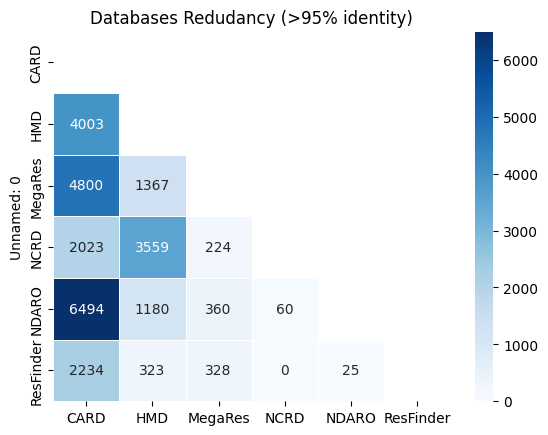

In [131]:
BlastPairWiseAlignmentPivoted = pd.read_csv("../data/processed/BlastPairWiseAlignmentPivoted.cov80.maxseq1.csv", sep="\t")
mask = np.triu(np.ones_like(BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"), dtype=bool)) 
sns.heatmap(
    BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"),
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidth=.5,
    mask=mask,
)
plt.title("Databases Redudancy (>95% identity)")

In [132]:
BlastPairWiseAlignmentPivoted

,Unnamed: 0,CARD,HMD,MegaRes,NCRD,NDARO,ResFinder
0,CARD,26.0,2864.0,1775.0,83.0,1295.0,0.0
1,HMD,4003.0,6884.0,1277.0,1980.0,348.0,6.0
2,MegaRes,4800.0,1367.0,159.0,63.0,286.0,188.0
3,NCRD,2023.0,3559.0,224.0,4945.0,133.0,1.0
4,NDARO,6494.0,1180.0,360.0,60.0,936.0,23.0
5,ResFinder,2234.0,323.0,328.0,0.0,25.0,5.0


Text(0, 0.5, 'Database Size')

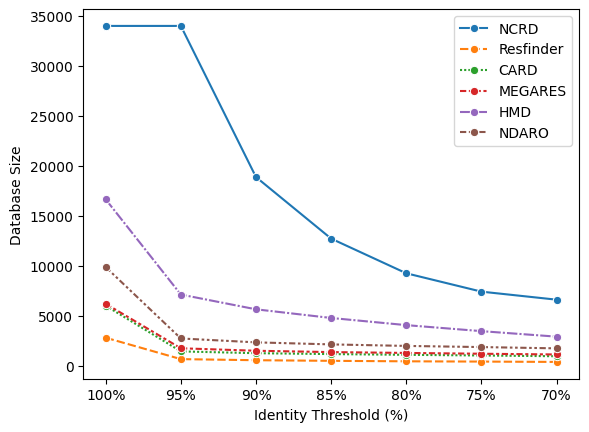

In [133]:
ClustersCdHit = pd.read_csv(
    "../data/processed/cdhitclusters.defaultsettings.csv",
    sep = "\t",
)
sns.lineplot(
    ClustersCdHit.set_index("Unnamed: 0"),
    marker = "o"
)
plt.xlabel("Identity Threshold (%)")
plt.ylabel("Database Size")

In [134]:
ClustersCdHit

,Unnamed: 0,NCRD,Resfinder,CARD,MEGARES,HMD,NDARO
0,100%,34008,2830,6027,6220,16666,9892
1,95%,34008,690,1462,1774,7147,2755
2,90%,18893,580,1283,1527,5670,2366
3,85%,12739,519,1194,1393,4805,2162
4,80%,9273,471,1120,1308,4089,2010
5,75%,7437,444,1053,1228,3487,1895
6,70%,6634,410,978,1155,2937,1766


In [135]:
PairWiseAlignment = pd.read_csv(
    "../data/filtered/AllDatabases.Paiwise.cov80.maxseq1.tsv", 
    sep = "\t",
    skipinitialspace=True, 
    header=None,
    names = "qseqid sseqid stitle pident length qlen slen qstart qend sstart send evalue bitscore ppos full_qseq full_sseq".split(" ")
)
PairWiseAlignment["qcov"] = np.round((PairWiseAlignment["qend"] - PairWiseAlignment["qstart"] + 1) / (PairWiseAlignment["qlen"]) * 100, 2)
PairWiseAlignment["scov"] = np.round((PairWiseAlignment["send"] - PairWiseAlignment["sstart"] + 1) / (PairWiseAlignment["slen"]) * 100, 2)
PairWiseAlignment["qseqtag"] = PairWiseAlignment["qseqid"].str.split("|").str[1]
PairWiseAlignment["sseqtag"] = PairWiseAlignment["sseqid"].str.split("|").str[1]
PairWiseAlignment["qseqid"] = PairWiseAlignment["qseqid"].str.split("|").str[0]
PairWiseAlignment["sseqid"] = PairWiseAlignment["sseqid"].str.split("|").str[0]

In [136]:
PairWiseAlignment

,qseqid,sseqid,stitle,pident,length,qlen,slen,qstart,qend,sstart,send,evalue,bitscore,ppos,full_qseq,full_sseq,qcov,scov,qseqtag,sseqtag
0,CARD_0,MEGARES_1086,MEGARES_1086|MEGARES,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.0,CARD,MEGARES
1,CARD_1,HMD_829,HMD_829|HMD,100.0,286,286,286,1,286,1,286,3.950000e-201,551.0,100.0,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,100.0,100.0,CARD,HMD
2,CARD_2,NCRD_0,NCRD_0|NCRD,100.0,164,164,164,1,164,1,164,3.190000e-117,328.0,100.0,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,100.0,100.0,CARD,NCRD
3,CARD_3,HMD_1374,HMD_1374|HMD,100.0,291,291,291,1,291,1,291,6.060000e-203,556.0,100.0,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,100.0,100.0,CARD,HMD
4,CARD_4,HMD_247,HMD_247|HMD,100.0,270,270,270,1,270,1,270,2.890000e-195,535.0,100.0,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,100.0,100.0,CARD,HMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76568,RESFINDER_2918,CARD_4513,CARD_4513|CARD,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76569,RESFINDER_2919,CARD_4474,CARD_4474|CARD,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76570,RESFINDER_2920,CARD_4512,CARD_4512|CARD,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76571,RESFINDER_2921,CARD_4473,CARD_4473|CARD,100.0,539,539,539,1,539,1,539,0.000000e+00,1077.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD


<Axes: xlabel='qcov', ylabel='pident'>

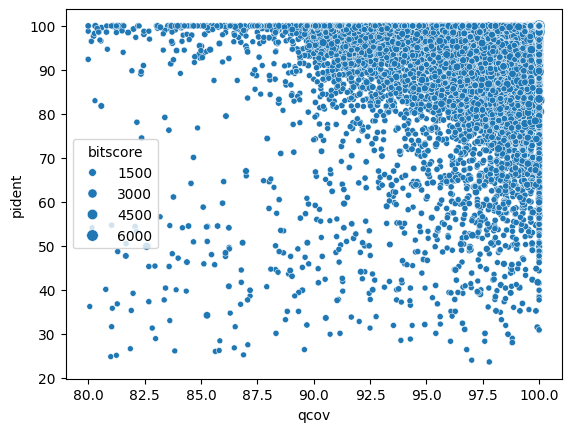

In [137]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 70], 
    x="qcov", 
    y="pident",
    size = "bitscore",
    )

<Axes: xlabel='pident', ylabel='ppos'>

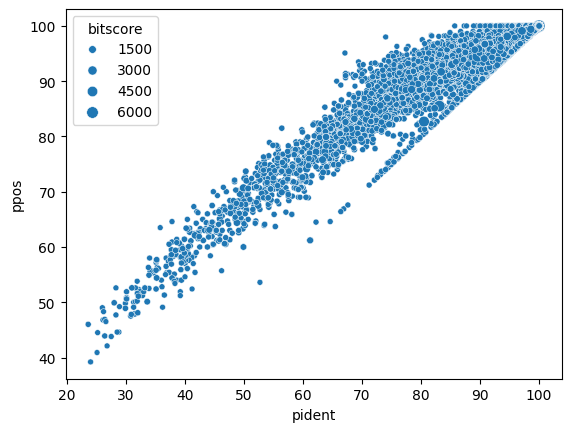

In [138]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 80], 
    x="pident", 
    y="ppos",
    size = "bitscore",
    )

<Axes: xlabel='pident', ylabel='Count'>

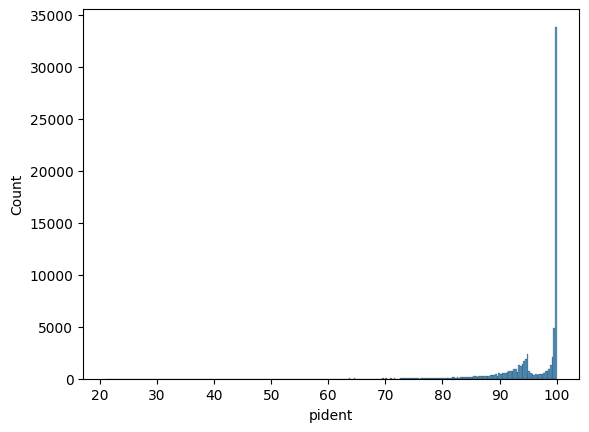

In [139]:
sns.histplot(PairWiseAlignment.pident)

In [140]:
PairWiseAlignment

,qseqid,sseqid,stitle,pident,length,qlen,slen,qstart,qend,sstart,send,evalue,bitscore,ppos,full_qseq,full_sseq,qcov,scov,qseqtag,sseqtag
0,CARD_0,MEGARES_1086,MEGARES_1086|MEGARES,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.0,CARD,MEGARES
1,CARD_1,HMD_829,HMD_829|HMD,100.0,286,286,286,1,286,1,286,3.950000e-201,551.0,100.0,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,100.0,100.0,CARD,HMD
2,CARD_2,NCRD_0,NCRD_0|NCRD,100.0,164,164,164,1,164,1,164,3.190000e-117,328.0,100.0,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,100.0,100.0,CARD,NCRD
3,CARD_3,HMD_1374,HMD_1374|HMD,100.0,291,291,291,1,291,1,291,6.060000e-203,556.0,100.0,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,100.0,100.0,CARD,HMD
4,CARD_4,HMD_247,HMD_247|HMD,100.0,270,270,270,1,270,1,270,2.890000e-195,535.0,100.0,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,100.0,100.0,CARD,HMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76568,RESFINDER_2918,CARD_4513,CARD_4513|CARD,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76569,RESFINDER_2919,CARD_4474,CARD_4474|CARD,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76570,RESFINDER_2920,CARD_4512,CARD_4512|CARD,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76571,RESFINDER_2921,CARD_4473,CARD_4473|CARD,100.0,539,539,539,1,539,1,539,0.000000e+00,1077.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD


In [141]:
with open("../data/processed/MetaDict.cov80.maxseq1.json", "r") as json_file  :
    MetaDict = json.load(json_file)

In [142]:
SequenceSimilarityGraph = nx.from_pandas_edgelist(
    PairWiseAlignment.loc[PairWiseAlignment["pident"] > 95], 
    source="qseqid", 
    target="sseqid", 
    edge_attr=["pident", "evalue","bitscore", "ppos"]
)
nx.set_node_attributes(SequenceSimilarityGraph, MetaDict)
ConnectedComponents = list(nx.connected_components(SequenceSimilarityGraph))
len(ConnectedComponents)

13420

In [143]:
ProblematicComponents = set()
ComponentIndex = dict()
DivergenteAnnotatedClasses = []
for i, component in enumerate(ConnectedComponents):
    ComponentGraph = SequenceSimilarityGraph.subgraph(component)
    Classes = [ComponentGraph.nodes[n].get("Drug Class") for n in component]
    if len(set(Classes)) > 1:
        ComponentIndex[i] = {"status": "problematic", "component": component, "classes": set(Classes), "len": len(component), "compindex" : i}
        ProblematicComponents = ProblematicComponents.union(component)
        DivergenteAnnotatedClasses.append(set(Classes))
    else:
        ComponentIndex[i] = {"status": "ok", "component": component, "classes": set(Classes), "len": len(component), "compindex":i}

In [144]:
SetCount = Counter(frozenset(sorted(s)) for s in DivergenteAnnotatedClasses)
SetCountList = []
for Set,Total in SetCount.items():
    label = "{"+", ".join(sorted(list(Set)))+"}"
    SetCountList.append({"Set":label, "Total":Total})
SetCount = pd.DataFrame(SetCountList)
SetCount.sort_values(by = "Total", ascending = False)


,Set,Total
317,"{bacitracin, glycopeptide}",968
6,"{fluoroquinolone, quinolone}",223
5,"{fosfomycin, phosphonic acid}",148
29,"{MLS, ml}",80
24,"{chloramphenicol, phenicol}",74
...,...,...
385,"{glycopeptide, macrolide}",1
384,"{MLS, fluoroquinolone}",1
396,"{antibacterial free fatty acid, drug_and_bioci...",1
382,"{glycopeptide, lipopeptide, polymyxin}",1


/tmp/ipykernel_47277/2318550877.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout() # Ajusta o layout para não cortar os nomes longos


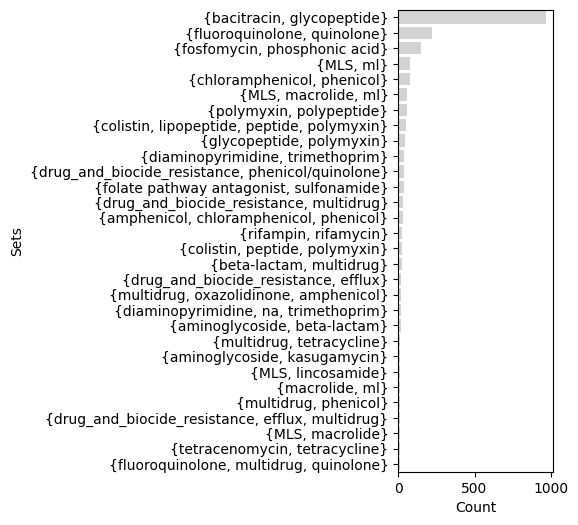

In [145]:
plt.figure(figsize=(2, 6))
sns.barplot(
    data=SetCount.sort_values(
        by = "Total", ascending = False).head(30), 
        x='Total', 
        y='Set', 
        color ='lightgrey')

plt.xlabel('Count')
plt.ylabel('Sets')
plt.tight_layout() # Ajusta o layout para não cortar os nomes longos

plt.show()

<Axes: >

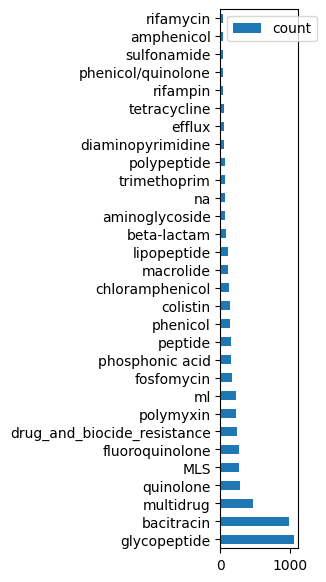

In [146]:
ClassCount = []
for item in pd.Series(DivergenteAnnotatedClasses):
    for c in item:
        ClassCount.append(c)
pd.Series(ClassCount).value_counts().head(30).to_frame().plot(kind = "barh", figsize=(1,7))

<Axes: >

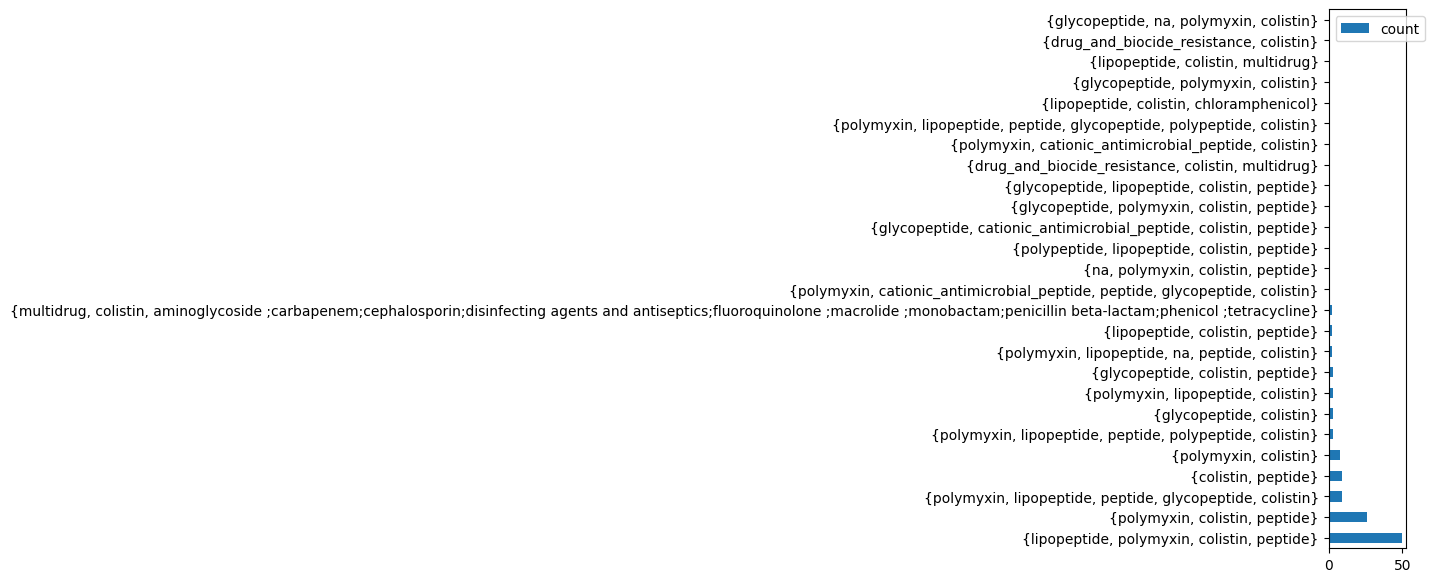

In [147]:
TargetClass = "colistin"
pd.Series([c for c in DivergenteAnnotatedClasses if TargetClass in c]).value_counts().head(30).to_frame().plot(kind = "barh", figsize=(1,7))

## Networks

In [148]:
color_map = {
    'multidrug':      "#FD6F63",     
    'beta-lactam':    "#89BDE7",  
    'bacitracin':     "#2E8D19",    
    'tetracycline':   "#CD73E8",
    'glycopeptide':   "#F3BC71",  
    'macrolide':      "#D4D451",     
    'aminoglycoside': "#ECAD2F", 
    'quinolone':      "#14E974",
    'drug_and_biocide_resistance': "#EA17B9",
    "drug_and_biocide_and_metal_resistance": "#EA17B9",
    'fosfomycin':     "#6063F4",
    'fluoroquinolone':"#60D4F4",
    'elfamycin':      "#7B079E",
    'aminocoumarin':  "#EE00F6",
    'rifampin':       "#0BF8E8",
    'phosphonic acid':"#262897",
    'fosmidomycin':   "#7B5404",
    'colistin' :      "#7FBE03",
    'polymyxin':      "#97B262",
    'GenomeProtein':"#534F51",
    }

In [149]:
# TargetClass = "fosfomycin"
ProblematicCompWithTargetClass = set()
for key, value in ComponentIndex.items():
    if value["status"] == "problematic":
        if TargetClass in value["classes"]:
            ProblematicCompWithTargetClass = ProblematicCompWithTargetClass.union(value["component"])
ProblematicComponentsByClass = SequenceSimilarityGraph.subgraph(ProblematicCompWithTargetClass)
nx.write_graphml(ProblematicComponentsByClass, f"../data/processed/ProblematicComponentsByClass.{TargetClass}.graphml")


meu_layout = {
    "scalingRatio": 50.0,           # Aumente para afastar os grupos
    "gravity": 0.2,                 # Reduza para não amontoar no centro
    "repulsion": 2,               # Aumente para afastar os nós
    # "outboundAttractionDistribution": True, # Empurra hubs para fora
    # "barnesHutOptimize": True,      # Essencial para seus 70k nós
    # "linLogMode": True              # Melhora a definição de clusters biológicos 
}
Sigma(
    ProblematicComponentsByClass, 
    node_size  = ProblematicComponentsByClass.degree(), 
    node_color =  [ProblematicComponentsByClass.nodes[n].get("Drug Class") for n in ProblematicComponentsByClass.nodes()],
    raw_node_color=True,
    node_color_palette = color_map,
    # node_metrics={"community": "louvain"},

    default_edge_type = "curve",
    layout_settings=meu_layout,
    start_layout=30,
    )

Sigma(nx.Graph with 547 nodes and 413 edges)

In [160]:
outdir = Path("../data/processed/selected_components")
outdir.mkdir(parents=True, exist_ok=True)

for TargetClass in color_map.keys():
    if TargetClass != "GenomeProtein":
        print(TargetClass.replace(' ','_'))
        nx.write_graphml(ProblematicComponentsByClass, f"../data/processed/ProblematicComponentsByClass.{TargetClass.replace(' ','_')}.graphml")
        with open(f"{outdir}/ProblematicComponents.TargetClass.{TargetClass.replace(' ','_')}.fasta", "w+") as ProblematiComponentsFastaFile:
            for ProteinNode in ProblematicComponentsByClass.nodes:
                try:
                    NodeClass = ProblematicComponentsByClass.nodes[ProteinNode]["Drug Class"]
                    NodeSequence = ProblematicComponentsByClass.nodes[ProteinNode]["Sequence"]
                except:
                    pass
                ProblematiComponentsFastaFile.write(f">{ProteinNode}|{NodeClass}\n{NodeSequence}\n")

multidrug
beta-lactam
bacitracin
tetracycline
glycopeptide
macrolide
aminoglycoside
quinolone
drug_and_biocide_resistance
drug_and_biocide_and_metal_resistance
fosfomycin
fluoroquinolone
elfamycin
aminocoumarin
rifampin
phosphonic_acid
fosmidomycin
colistin
polymyxin


In [ ]:
outdir = Path("../data/processed/selected_components")
outdir.mkdir(parents=True, exist_ok=True)


with open(f"{outdir}/ProblematicComponents.TargetClass.{TargetClass}.fasta", "w+") as ProblematiComponentsFastaFile:
    for ProteinNode in ProblematicComponentsByClass.nodes:
        try:
            NodeClass = ProblematicComponentsByClass.nodes[ProteinNode]["Drug Class"]
            NodeSequence = ProblematicComponentsByClass.nodes[ProteinNode]["Sequence"]
        except:
            pass
        ProblematiComponentsFastaFile.write(f">{ProteinNode}|{NodeClass}\n{NodeSequence}\n")
        # print(f">{ProteinNode}|{NodeClass}\n{NodeSequence}\n")

In [152]:
ProblematicCompoLenDist = [value["len"] for key, value in ComponentIndex.items() if value["status"] == "problematic"]

Text(0.5, 1.0, 'Distribution of Problematic Component Sizes')

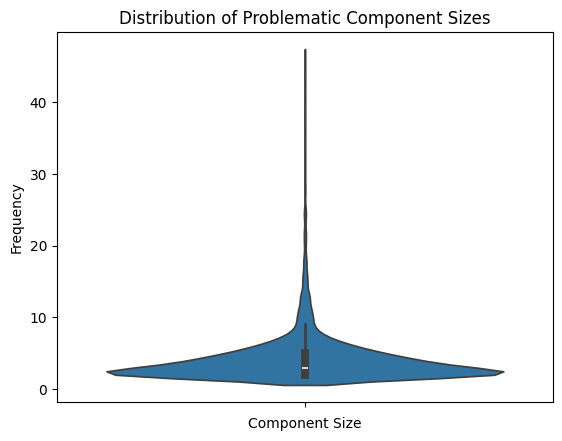

In [153]:
sns.violinplot(ProblematicCompoLenDist)
plt.xlabel("Component Size")
plt.ylabel("Frequency")
plt.title("Distribution of Problematic Component Sizes")

In [154]:
ProblematicCompoClassDist = [len(value["classes"]) for key, value in ComponentIndex.items() if value["status"] == "problematic"]

Text(0.5, 1.0, 'Distribution of Number of Classes in Problematic Component Sizes')

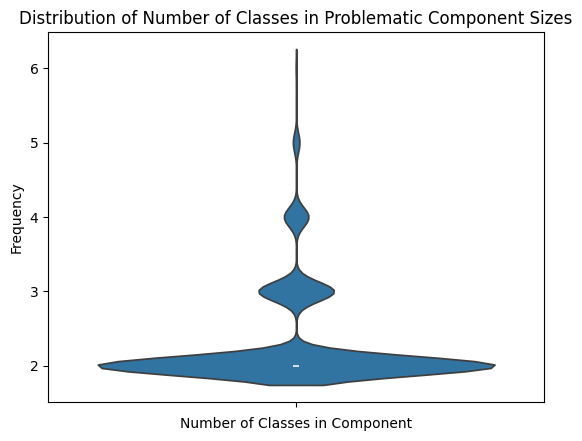

In [155]:
sns.violinplot(ProblematicCompoClassDist)
plt.xlabel("Number of Classes in Component")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Classes in Problematic Component Sizes")

In [156]:
def ConcateComponentsBy(CompDict, OriginalGraph, Minsize = None, MinClassNumber = None):
    if Minsize is None and MinClassNumber is None:
        raise ValueError("At least one of Minsize or MinClassNumber must be provided. Both cannot be None.")
    elif Minsize is not None and MinClassNumber is not None:
        raise ValueError("Only one of Minsize or MinClassNumber can be provided. Both cannot be set at the same time.")
    
    ConcateComponents = set()
    for key, value in CompDict.items():
        if Minsize is not None and value["len"] >= Minsize and value["status"] == "problematic":
            ConcateComponents = ConcateComponents.union(value["component"])

        elif MinClassNumber is not None and len(value["classes"]) >= MinClassNumber and value["status"] == "problematic":
            ConcateComponents = ConcateComponents.union(value["component"])            
    return OriginalGraph.subgraph(ConcateComponents),ConcateComponents